In [7]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

categories = ['Login Issue', 'Payment Problem', 'Performance Issue', 
              'Data Sync Issue', 'Bug Report', 'Feature Request', 
              'Account Suspension', 'Subscription Cancellation']

data = {
    'ticket_id': range(1001, 1001 + n),
    'category': np.random.choice(categories, n),
    'resolution_time_hours': np.random.normal(120, 60, n).clip(5, 300)
}

df = pd.DataFrame(data)

# Introduce messiness
blank_mask = np.random.rand(n) < 0.12
df.loc[blank_mask, 'resolution_time_hours'] = np.nan

outlier_mask = np.random.rand(n) < 0.05
df.loc[outlier_mask, 'resolution_time_hours'] = np.random.choice(
    [999999, 9999, -50, 5000], size=outlier_mask.sum()
)

# Typos
typo_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[typo_idx, 'category'] = df.loc[typo_idx, 'category'].replace({
    'Bug Report': 'Bug Rep0rt', 
    'Data Sync Issue': 'Data Sync Issu3'
})

df.to_csv("synthetic_customer_support_tickets_messy.csv", index=False)
print("✅Messy dataset saved as 'synthetic_customer_support_tickets_messy.csv'")
print("Shape:", df.shape)
print("Missing values:", df['resolution_time_hours'].isna().sum())
print(df['resolution_time_hours'].describe())

✅Messy dataset saved as 'synthetic_customer_support_tickets_messy.csv'
Shape: (1000, 3)
Missing values: 128
count       872.000000
mean      15189.985015
std      121225.860144
min         -50.000000
25%          81.751480
50%         123.959787
75%         165.427103
max      999999.000000
Name: resolution_time_hours, dtype: float64


In [8]:
import pandas as pd
import numpy as np

df=pd.read_csv("synthetic_customer_support_tickets_messy.csv") 

print("Shape:",df.shape)
print("Columns:",df.columns.tolist())

# Key columns 
print("\nMissing values in key columns:")
print(df[['category','resolution_time_hours']].isnull().sum())

# Original statistics
print("\nOriginal Resolution Time Statistics")
print(df['resolution_time_hours'].describe())

# Step 1: Detecting Outliers using IQR Method
Q1=df['resolution_time_hours'].quantile(0.25)
Q3=df['resolution_time_hours'].quantile(0.75)
IQR = Q3-Q1

lower_b=Q1-1.5*IQR
upper_b=Q3+1.5*IQR

print("\nIQR Outlier Detection")
print(f"Q1:{Q1:.2f} | Q3:{Q3:.2f} | IQR:{IQR:.2f}")
print(f"Lower boundary: {lower_b:.2f}")
print(f"Upper boundary: {upper_b:.2f}")

outliers = df[(df['resolution_time_hours'] < lower_b) | 
              (df['resolution_time_hours'] > upper_b)]
print(f"Number of outliers detected: {len(outliers)}")

# Step 2: Cleaning the data
clean_df = df[(df['resolution_time_hours'] >= lower_b) & 
              (df['resolution_time_hours'] <= upper_b)].copy()

# Fill any remaining Nans with median 
clean_df['resolution_time_hours'] = clean_df.groupby('category')['resolution_time_hours'].transform(
    lambda x: x.fillna(x.median())
)

print("\nAfter cleaning shape:",clean_df.shape)
print("Cleaned Resolution Time Stats:")
print(clean_df['resolution_time_hours'].describe())


# Step 3: Some insights

avg_time=clean_df['resolution_time_hours'].mean()
print(f"\nOverall Average Resolution Time:{avg_time:.2f} hours")

by_category=clean_df.groupby('category')['resolution_time_hours'].mean() \
              .sort_values(ascending=False)

print("\nTop 5 Categories with Longest Average Resolution Time:")
print(by_category.head(5))

Shape: (1000, 3)
Columns: ['ticket_id', 'category', 'resolution_time_hours']

Missing values in key columns:
category                   0
resolution_time_hours    128
dtype: int64

Original Resolution Time Statistics
count       872.000000
mean      15189.985015
std      121225.860144
min         -50.000000
25%          81.751480
50%         123.959787
75%         165.427103
max      999999.000000
Name: resolution_time_hours, dtype: float64

IQR Outlier Detection
Q1:81.75 | Q3:165.43 | IQR:83.68
Lower boundary: -43.76
Upper boundary: 290.94
Number of outliers detected: 47

After cleaning shape: (825, 3)
Cleaned Resolution Time Stats:
count    825.000000
mean     122.471434
std       58.815373
min        5.000000
25%       82.381977
50%      122.786193
75%      160.180353
max      277.942924
Name: resolution_time_hours, dtype: float64

Overall Average Resolution Time:122.47 hours

Top 5 Categories with Longest Average Resolution Time:
category
Data Sync Issu3       149.311623
Payment Pr


Average Resolution Time: 122.47 hours

Top 5 Slowest Categories:
category
Data Sync Issu3       149.311623
Payment Problem       127.707098
Bug Report            126.327406
Account Suspension    125.740403
Feature Request       122.558474
Name: resolution_time_hours, dtype: float64


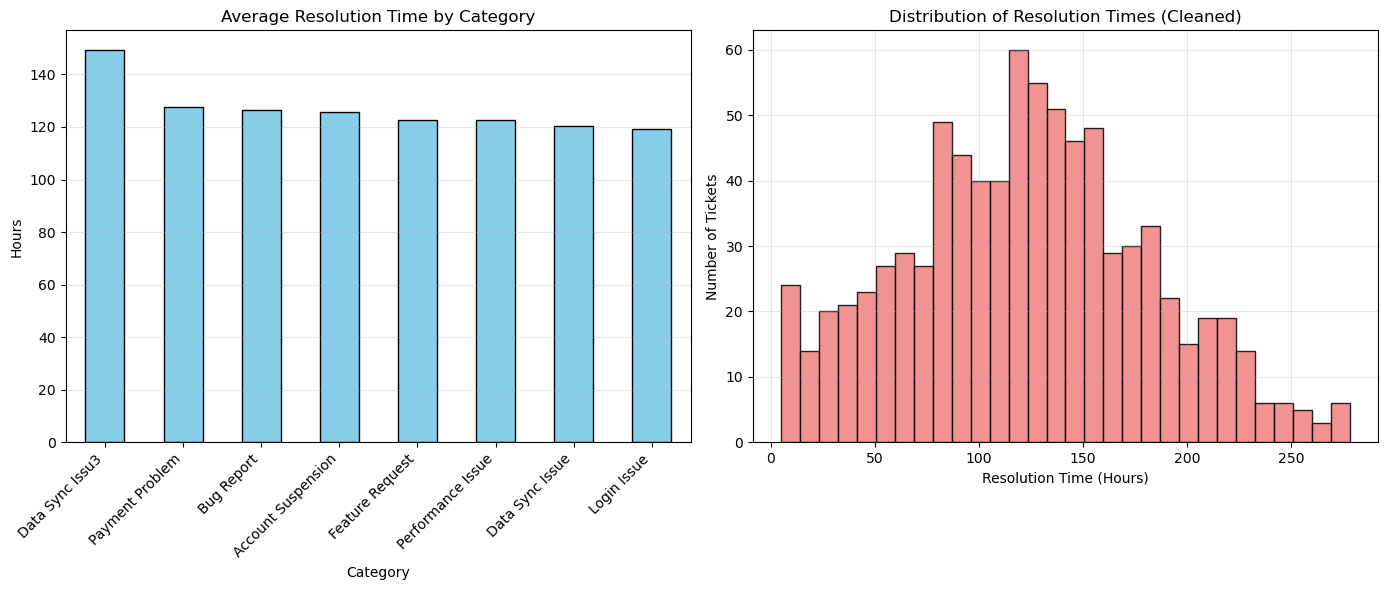

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

#Graphs
avg_time = clean_df['resolution_time_hours'].mean()
print(f"\nAverage Resolution Time: {avg_time:.2f} hours")

by_cat = clean_df.groupby('category')['resolution_time_hours'].mean().sort_values(ascending=False)
print("\nTop 5 Slowest Categories:")
print(by_cat.head(5))

plt.figure(figsize=(14, 6))

#Bar Chart
plt.subplot(1, 2, 1)
by_cat.head(8).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Resolution Time by Category')
plt.ylabel('Hours')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

#Histogram
plt.subplot(1, 2, 2)
plt.hist(clean_df['resolution_time_hours'], bins=30, color='lightcoral', edgecolor='black',alpha=0.85)
plt.title('Distribution of Resolution Times(Cleaned)')
plt.xlabel('Resolution Time(Hours)')
plt.ylabel('Number of Tickets')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Save image
plt.savefig('resolution_time_analysis.png', dpi=150)